#No 1

###A.EDA

In [ ]:
#library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
#load Dataset
df = pd.read_csv('/content/AP003.csv', parse_dates=['From Date']) # langsung membaca kolom 'From Date' sebagai tipe datetime, bukan string
#Agar kolom waktu bisa langsung dipakai untuk operasi time series
#Tanpa parse_dates, kolom tersebut akan dibaca sebagai string (object dtype), yang tidak bisa langsung diolah sebagai tanggal

df = df.rename(columns=lambda x: x.strip()) #untuk menghapus spasi di awal/akhir nama kolom
#Jika tidak dibersihkan,bisa dapat error walaupun kolomnya terlihat ada tapi ternyata ada spasi tersembunyi
df.head()

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
0,2017-07-01 00:00:00,2017-07-01 01:00:00,50.00,91.75,3.33,27.70,17.48,NaN,24.35,1.33,...,55.22,83.25,1.67,285.50,6.75,737.0,0.03,26.30,0.00,0.65
1,2017-07-01 01:00:00,2017-07-01 02:00:00,30.75,59.25,1.20,20.78,11.40,0.03,8.23,1.77,...,57.48,84.50,2.50,299.50,6.75,736.0,0.05,25.00,1.50,0.50
2,2017-07-01 02:00:00,2017-07-01 03:00:00,NaN,NaN,1.17,4.07,2.73,0.10,10.77,1.20,...,58.67,86.00,0.77,285.67,6.67,736.0,0.03,24.17,0.33,0.43
3,2017-07-01 03:00:00,2017-07-01 04:00:00,8.00,NaN,2.58,6.38,5.30,NaN,19.78,1.58,...,58.93,86.00,1.55,302.50,6.00,735.0,0.08,24.10,0.00,0.63
4,2017-07-01 04:00:00,2017-07-01 05:00:00,33.25,NaN,5.30,21.03,15.47,0.15,22.40,2.25,...,59.88,86.00,2.30,297.25,6.00,735.0,0.08,24.90,0.00,0.67


In [ ]:
# Bersihkan nama kolom dari satuan dan spasi
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r"\s*\(.*\)", "", regex=True)

In [ ]:
#cek ada kolom apa aja di dataset
print(df.columns)

Index(['From Date', 'To Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'SO2', 'CO', 'Ozone', 'Benzene', 'Toluene', 'Temp', 'RH', 'WS', 'WD',
       'SR', 'BP', 'VWS', 'AT', 'RF', 'Xylene'],
      dtype='object')


In [ ]:
#cek struktur data (tipe data, missing value)
print("Struktur DataFrame:")
df.info()

Struktur DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   From Date  50400 non-null  datetime64[ns]
 1   To Date    50400 non-null  object        
 2   PM2.5      44691 non-null  float64       
 3   PM10       45018 non-null  float64       
 4   NO         46252 non-null  float64       
 5   NO2        45705 non-null  float64       
 6   NOx        47040 non-null  float64       
 7   NH3        45756 non-null  float64       
 8   SO2        43604 non-null  float64       
 9   CO         46993 non-null  float64       
 10  Ozone      45309 non-null  float64       
 11  Benzene    46678 non-null  float64       
 12  Toluene    46678 non-null  float64       
 13  Temp       46335 non-null  float64       
 14  RH         46520 non-null  float64       
 15  WS         46522 non-null  float64       
 16  WD         44710 non

In [ ]:
print("\n Contoh data awal:")
print(df.head())


 Contoh data awal:
            From Date              To Date  PM2.5   PM10    NO    NO2    NOx  \
0 2017-07-01 00:00:00  2017-07-01 01:00:00  50.00  91.75  3.33  27.70  17.48   
1 2017-07-01 01:00:00  2017-07-01 02:00:00  30.75  59.25  1.20  20.78  11.40   
2 2017-07-01 02:00:00  2017-07-01 03:00:00    NaN    NaN  1.17   4.07   2.73   
3 2017-07-01 03:00:00  2017-07-01 04:00:00   8.00    NaN  2.58   6.38   5.30   
4 2017-07-01 04:00:00  2017-07-01 05:00:00  33.25    NaN  5.30  21.03  15.47   

    NH3    SO2    CO  ...   Temp     RH    WS      WD    SR     BP   VWS  \
0   NaN  24.35  1.33  ...  55.22  83.25  1.67  285.50  6.75  737.0  0.03   
1  0.03   8.23  1.77  ...  57.48  84.50  2.50  299.50  6.75  736.0  0.05   
2  0.10  10.77  1.20  ...  58.67  86.00  0.77  285.67  6.67  736.0  0.03   
3   NaN  19.78  1.58  ...  58.93  86.00  1.55  302.50  6.00  735.0  0.08   
4  0.15  22.40  2.25  ...  59.88  86.00  2.30  297.25  6.00  735.0  0.08   

      AT    RF  Xylene  
0  26.30  0.00   

Fungsi df.head() digunakan untuk melihat 5 baris pertama dari dataset.  
Tujuannya adalah untuk:
- Memastikan data berhasil diimpor dengan benar
- Mengecek format kolom waktu, angka, dan apakah ada data kosong
- Melihat struktur dasar data sebelum dilakukan transformasi



In [ ]:
df.shape

(50400, 23)

Dataset memiliki dimensi (50400, 23), yang berarti:
- 50400 baris data (time steps), kemungkinan merupakan data hourly → setara dengan lebih dari 5 tahun pengamatan
- 23 kolom fitur, termasuk From Date, AT, dan berbagai sensor polusi udara serta cuaca




In [ ]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Unique values in '{col}': (jumlah: {len(unique_vals)})")
    print(unique_vals[:10], "...")  # hanya tampilkan 10 nilai pertama
    print("-" * 50)

Unique values in 'From Date': (jumlah: 50400)
<DatetimeArray>
['2017-07-01 00:00:00', '2017-07-01 01:00:00', '2017-07-01 02:00:00',
 '2017-07-01 03:00:00', '2017-07-01 04:00:00', '2017-07-01 05:00:00',
 '2017-07-01 06:00:00', '2017-07-01 07:00:00', '2017-07-01 08:00:00',
 '2017-07-01 09:00:00']
Length: 10, dtype: datetime64[ns] ...
--------------------------------------------------
Unique values in 'To Date': (jumlah: 50400)
['2017-07-01 01:00:00' '2017-07-01 02:00:00' '2017-07-01 03:00:00'
 '2017-07-01 04:00:00' '2017-07-01 05:00:00' '2017-07-01 06:00:00'
 '2017-07-01 07:00:00' '2017-07-01 08:00:00' '2017-07-01 09:00:00'
 '2017-07-01 10:00:00'] ...
--------------------------------------------------
Unique values in 'PM2.5': (jumlah: 1183)
[50.   30.75   nan  8.   33.25 32.67 27.75 38.   35.33 27.  ] ...
--------------------------------------------------
Unique values in 'PM10': (jumlah: 2424)
[ 91.75  59.25    nan  25.    81.    93.    70.    79.5  108.33 140.  ] ...
-----------------

Nilai Unik per Kolom

Untuk memahami cakupan dan format nilai dari setiap kolom, digunakan `df[col].unique()` secara iteratif.

Tujuannya:
- Mengidentifikasi nilai aneh (misalnya 999, 'N/A', dll)
- Memastikan kolom numerik tidak berisi string
- Membantu dalam tahap pembersihan dan encoding sebelum modeling


**CEK DUPLICATE**

In [ ]:
#untuk menghitung total baris duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
#menghapus seluruh baris yang identik secara penuh
df.drop_duplicates(inplace=True)
print(f"Dataset shape after dropping duplicates: {df.shape}")

Dataset shape after dropping duplicates: (50400, 23)


Tidak ditemukan baris duplikat (jumlah baris tetap 50400)

**DROP KOLOM YANG GA DIPAKAI**

In [ ]:
df.drop(columns=['To Date'], inplace=True)

* informasi waktu sudah cukup diwakili oleh From Date (misalnya data dicatat tiap jam).

* To Date hanya memberikan waktu selesai, yang bisa dihitung dari From Date + interval (misal: 1 jam).

* Tidak relevan untuk modeling, terutama pada prediksi suhu (AT) berbasis From Date.



In [ ]:
print(df.columns)

Index(['From Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO',
       'Ozone', 'Benzene', 'Toluene', 'Temp', 'RH', 'WS', 'WD', 'SR', 'BP',
       'VWS', 'AT', 'RF', 'Xylene'],
      dtype='object')


**CEK MISSING VALUE DAN PERSENTASE MISSING VALUE**

In [ ]:
df.isnull().sum()

,0
From Date,0
PM2.5,5709
PM10,5382
NO,4148
NO2,4695
NOx,3360
NH3,4644
SO2,6796
CO,3407
Ozone,5091


In [ ]:
round(df.isnull().sum()/len(df),3)

,0
From Date,0.000
PM2.5,0.113
PM10,0.107
NO,0.082
NO2,0.093
NOx,0.067
NH3,0.092
SO2,0.135
CO,0.068
Ozone,0.101


In [ ]:
#Cek tipe data & statistik umum
print("Descriptive Statistics:\n", df.describe())

Descriptive Statistics:
                  From Date         PM2.5          PM10            NO  \
count                50400  44691.000000  45018.000000  46252.000000   
mean   2020-05-15 23:30:00     46.869591    111.938589     14.817678   
min    2017-07-01 00:00:00      0.250000      1.000000      0.030000   
25%    2018-12-07 23:45:00     23.415000     63.330000      2.915000   
50%    2020-05-15 23:30:00     38.750000     97.750000      6.600000   
75%    2021-10-22 23:15:00     62.330000    137.500000     17.300000   
max    2023-03-31 23:00:00    840.000000    904.000000    419.780000   
std                    NaN     35.201161     74.285923     22.372042   

                NO2           NOx           NH3           SO2            CO  \
count  45705.000000  47040.000000  45756.000000  43604.000000  46993.000000   
mean      34.921808     29.857413     13.813287     12.323789      0.666865   
min        0.030000      0.000000      0.020000      0.030000      0.000000   
25%       



Statistik deskriptif memberikan ringkasan kuantitatif dari data numerik dalam dataset.

- Jumlah non-null (count)
- Rata-rata (mean)
- Minimum (min) dan maksimum (max)
- Kuartil 1 (25%), median (50%), dan kuartil 3 (75%)
- Simpangan baku (std)

---

Insight Penting dari Statistik Deskriptif:

**Ukuran Data:**
   - Mayoritas kolom memiliki data sekitar 45.000-47.000 entri dari total 50.400, menunjukkan adanya beberapa missing value yang perlu ditangani.
   
**Kualitas Udara:**
   - PM2.5 dan PM10 memiliki nilai maksimum sangat tinggi (hingga 840 dan 904) → kemungkinan outlier.
   - CO dan SO2 berada dalam rentang normal (maksimum CO: 11.28 mg/m³).

**Cuaca dan Lingkungan:**
   - Temp (suhu) berkisar dari 6.7°C hingga 59.88°C, dengan rata-rata sekitar 29.4°C
   - RH (kelembapan relatif) cukup tinggi secara umum, rata-rata 73%
   - AT (Air Temperature target) memiliki mean 27.59°C, dengan variasi cukup besar (std = 4.4)

**Fitur Khusus:**
   - RF (hujan) memiliki nilai median = 0, artinya kebanyakan jam tidak ada hujan.
   - SR (Solar Radiation) memiliki rentang sangat luas (0-730), menunjukkan variasi siang-malam.
   - Xylene, NH3, dan Benzene menunjukkan konsentrasi sangat bervariasi, kemungkinan dipengaruhi oleh jam/hari atau lokasi.

**Waspada terhadap Outlier:**
   - Nilai maksimum NO, NO2, SO2, Xylene, dan SR cukup ekstrem dibanding 75% tertinggi → perlu ditinjau di boxplot/outlier analysis.

---
Kesimpulan:

Statistik deskriptif menunjukkan bahwa dataset:
- Mengandung beberapa missing value
- Memiliki outlier pada beberapa kolom
- Bervariasi secara signifikan, mendukung penggunaan model multivariate time series
- Perlu pembersihan dan normalisasi sebelum digunakan dalam model LSTM


**VISUALISASI**

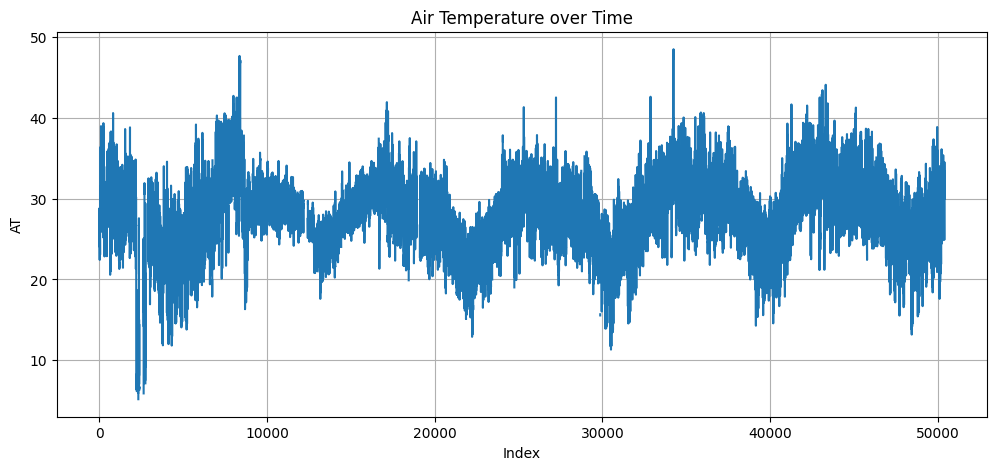

In [ ]:
#Visualisasi kolom penting
plt.figure(figsize=(12, 5))
df['AT'].plot(title='Air Temperature over Time')
plt.xlabel('Index'); plt.ylabel('AT')
plt.grid(True)
plt.show()

Grafik di atas menunjukkan pergerakan nilai Air Temperature (AT) terhadap indeks waktu pada dataset mentah.


---


Observasi:
- Data AT menunjukkan fluktuasi periodik, yang mengindikasikan adanya pola musiman atau siklikal.

- Terdapat beberapa lonjakan ekstrim baik ke atas maupun ke bawah, yang kemungkinan merupakan outlier atau anomali cuaca.

- Secara umum, nilai AT berkisar antara 5 hingga 45 derajat.


---


Kesimpulan:
Visualisasi ini sangat penting untuk memahami dinamika data sebelum dilakukan preprocessing atau modeling. Pola periodik yang terlihat dapat dimanfaatkan oleh model LSTM untuk mempelajari urutan data dan meningkatkan akurasi prediksi.

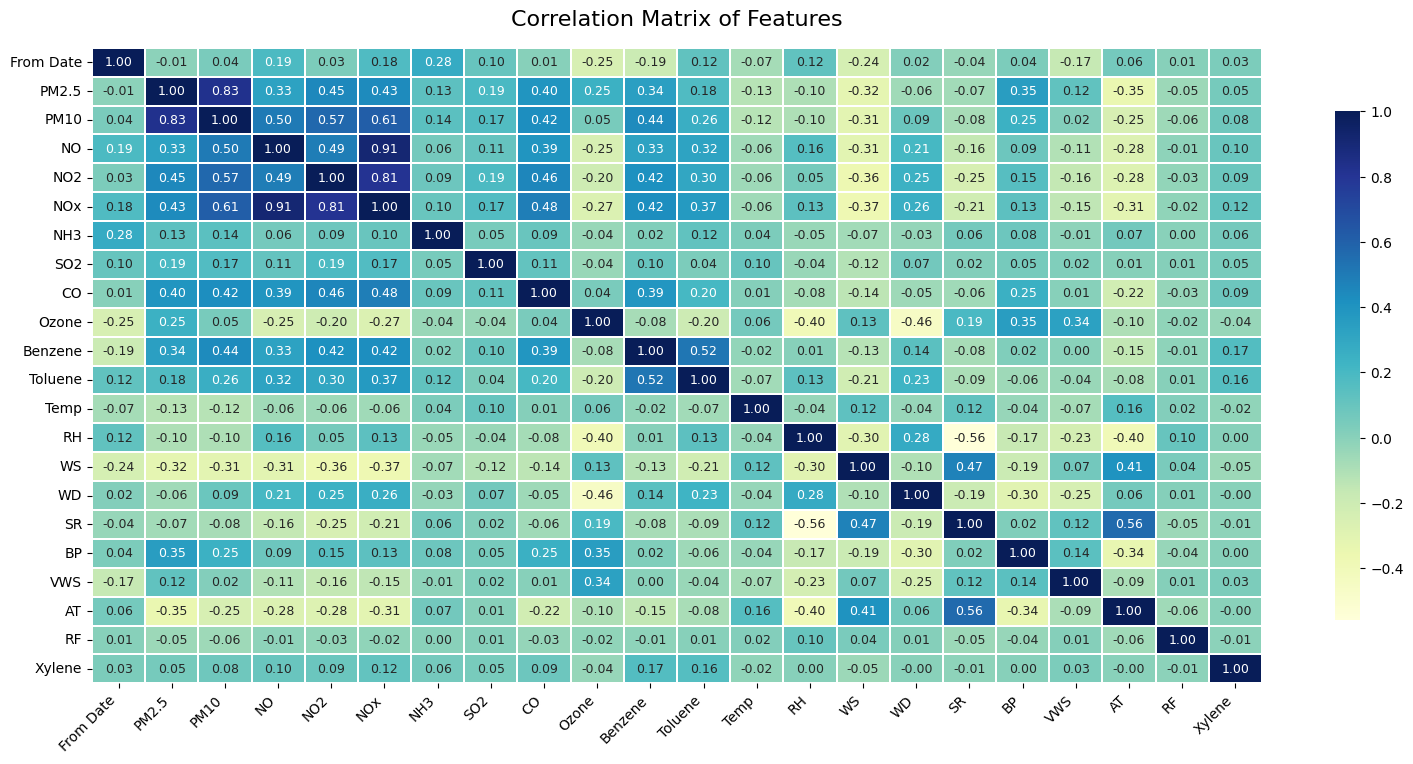

In [ ]:
# Heatmap Korelasi antar Fitur
plt.figure(figsize=(16, 8))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
plt.title("Correlation Matrix of Features", fontsize=16, pad=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout(pad=2)
plt.show()

Tujuan:
- Mengidentifikasi hubungan linear antara fitur-fitur
- Mengetahui apakah ada fitur yang saling berkorelasi tinggi (positif atau negatif)
- Menilai hubungan fitur terhadap target AT untuk membantu


---


pemilihan fitur dalam pemodelan
- Nilai korelasi berkisar antara -1 hingga 1:
  - +1 = korelasi positif sempurna
  - -1 = korelasi negatif sempurna
  - 0 = tidak ada korelasi linear
- Warna lebih gelap/hijau tua → korelasi tinggi  
- Warna lebih terang → korelasi rendah atau negatif



---
Observasi Utama:

Korelasi tinggi antar polutan:

- NO, NO2, dan NOx sangat berkorelasi satu sama lain (> 0.9), menunjukkan hubungan kimiawi yang erat.

- PM2.5 dan PM10 memiliki korelasi kuat (0.83), karena keduanya adalah partikel udara.

- AT (Air Temperature) memiliki korelasi negatif moderat terhadap beberapa fitur seperti:

    - PM2.5 (-0.35), NOx (-0.31), dan CO (-0.22).

    - Korelasi positif terhadap RH (0.41), WS (0.41), dan SR (0.56).

    - Ozone memiliki korelasi positif dengan SR (0.35) dan AT (0.34), masuk akal karena ozon permukaan meningkat di bawah sinar matahari yang kuat dan suhu tinggi.


---


Kesimpulan:

- Korelasi tinggi antar fitur dapat dimanfaatkan untuk feature selection atau dimensionality reduction.

- AT cukup terpengaruh oleh polutan dan cuaca, membuatnya layak untuk diprediksi menggunakan model time series seperti LSTM.


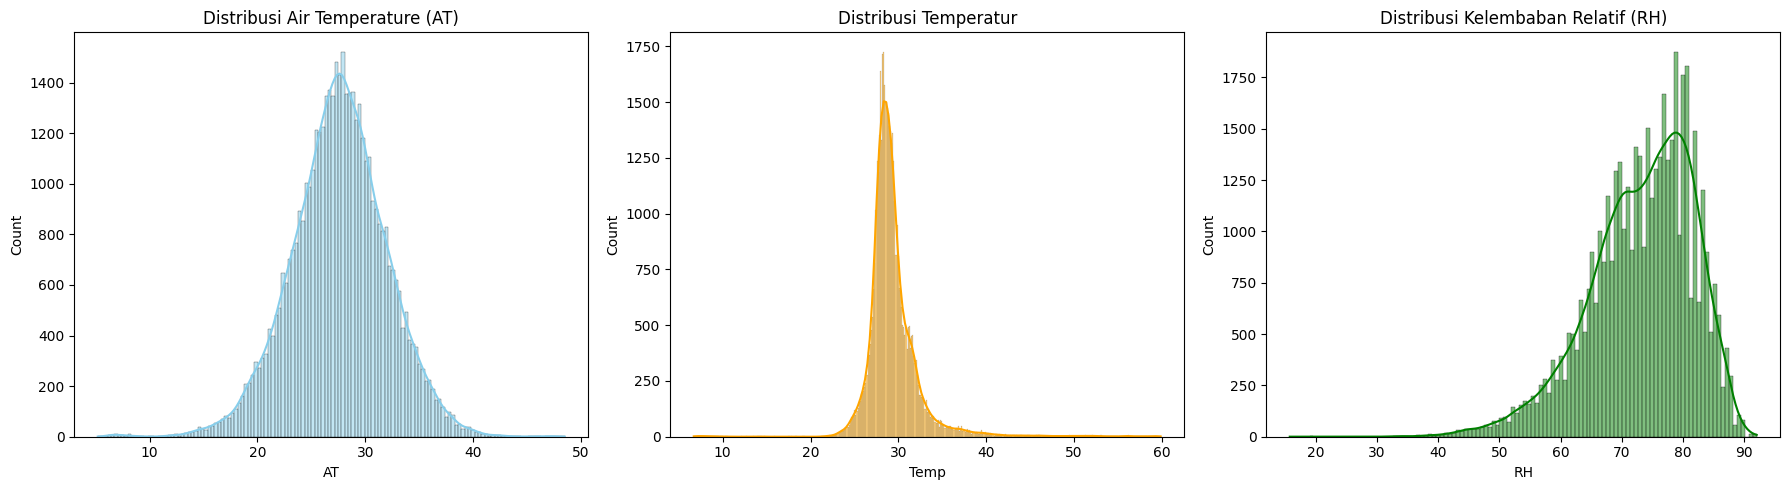

In [ ]:
#Distribusi fitur penting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['AT'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Air Temperature (AT)')
sns.histplot(df['Temp'].dropna(), kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribusi Temperatur')
sns.histplot(df['RH'].dropna(), kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribusi Kelembaban Relatif (RH)')
plt.tight_layout()
plt.show()


Visualisasi Distribusi Fitur Penting

Grafik di bawah ini menunjukkan distribusi dari tiga fitur utama dalam dataset, yaitu:
* Air Temperature (AT) -> target yang akan diprediksi
* Temperature (Temp) -> suhu lingkungan yang tercatat
* Relative Humidity (RH) -> kelembaban udara relatif

---
Tujuan Visualisasi:
- Memahami distribusi nilai dari fitur-fitur penting
- Menentukan apakah data tersebar normal, miring (skewed), atau memiliki outlier
- Membantu menentukan strategi transformasi atau normalisasi data


---
Hasil Visualisasi:

Grafik di atas menunjukkan distribusi dari tiga variabel cuaca penting dalam dataset kualitas udara, yaitu Air Temperature (AT), Temperatur (Temp), dan Kelembaban Relatif (RH).

Penjelasan Setiap Subplot:

**Distribusi Air Temperature (AT):**

- Distribusi berbentuk normal (simetris), berpusat di sekitar nilai 28-30°C.

- Penyebaran data cukup lebar, menunjukkan variasi suhu yang moderat.

- Ini menunjukkan data AT cukup seimbang dan cocok untuk diprediksi menggunakan model regresi atau time series.

**Distribusi Temperatur (Temp):**

- Distribusi ini tidak simetris (skewed right).

- Banyak nilai terkonsentrasi di sekitar 29°C, dengan ekor memanjang ke kanan (nilai lebih tinggi).

- Menandakan bahwa sebagian besar waktu suhu cukup stabil, tetapi kadang mengalami kenaikan ekstrem.

**Distribusi Kelembaban Relatif (RH):**
- Distribusi positif skewed, dengan konsentrasi tertinggi antara 70-85%.

- Menunjukkan bahwa kelembaban relatif sering berada dalam kisaran tinggi.

- Fluktuasi RH penting untuk diperhatikan karena sangat berpengaruh terhadap pembentukan ozon dan polutan udara lainnya.


---


Kesimpulan:

Distribusi dari ketiga fitur cuaca ini memberikan gambaran penting tentang karakteristik data. AT dan RH dapat menjadi fitur target maupun input penting dalam model prediksi kualitas udara berbasis LSTM.




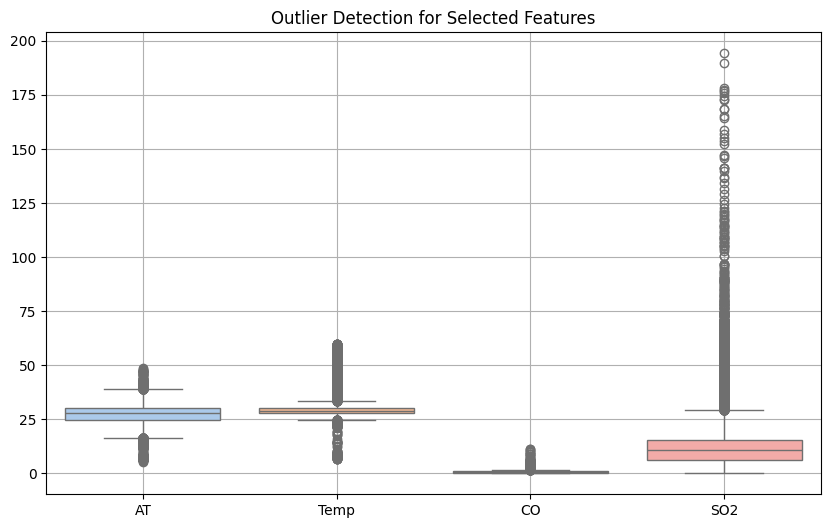

In [ ]:
#Deteksi outlier
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['AT', 'Temp', 'CO', 'SO2']], palette='pastel')
plt.title("Outlier Detection for Selected Features")
plt.grid(True)
plt.show()

Visualisasi boxplot ini membantu dalam:
- Mendeteksi nilai ekstrem yang bisa mengganggu model
- Menentukan strategi preprocessing yang tepat
- Menyempurnakan kualitas data sebelum masuk ke tahap modeling


---
Hasil Visualisasi:

Visualisasi di atas adalah boxplot yang digunakan untuk mendeteksi outlier pada empat fitur penting dalam dataset: AT (Air Temperature), Temp, CO, dan SO2.

Observasi:
- AT dan Temp:

Mayoritas data berada dalam rentang normal, tetapi ada sejumlah kecil outlier bawah dan atas, terutama pada suhu ekstrem.

- CO:

Hampir seluruh data berada dalam rentang yang wajar, dengan hanya sedikit outlier. Menunjukkan distribusi yang sangat sempit dan terkonsentrasi.

- SO2:

Memiliki jumlah outlier yang sangat banyak, terutama di sisi atas (nilai tinggi). Indikasi adanya pencemaran atau kejadian tidak normal yang harus dianalisis lebih lanjut atau ditangani dengan teknik capping, transformation, atau bahkan penghapusan.


In [ ]:
df['hour'] = df['From Date'].dt.hour
df['dayofweek'] = df['From Date'].dt.dayofweek

penambahan hour dan dayofweek sebagai fitur numerik waktu memberikan nilai tambah pada pemodelan time series multivariat dan memungkinkan model menangkap pola temporal yang lebih kompleks.
- Membantu model mengenali pola harian dan mingguan yang dapat memengaruhi suhu (AT)
- Memungkinkan LSTM belajar dari ritme waktu alami (misalnya: suhu cenderung lebih tinggi di siang hari)
- Mendukung prediksi yang mempertimbangkan waktu sebagai faktor implisit

/tmp/ipython-input-137-984086975.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='hour', y='AT', data=df, estimator='mean', ci=None, marker='o', color='teal')


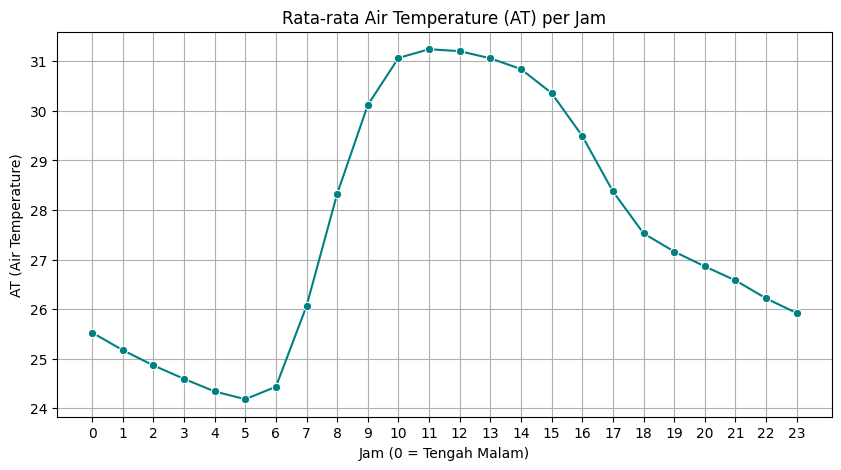

In [ ]:
# Plot rata-rata AT per jam
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='AT', data=df, estimator='mean', ci=None, marker='o', color='teal')
plt.title("Rata-rata Air Temperature (AT) per Jam")
plt.xlabel("Jam (0 = Tengah Malam)")
plt.ylabel("AT (Air Temperature)")
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

Tujuan Visualisasi:
- Mengidentifikasi pola harian pada suhu udara
- Melihat apakah terdapat jam-jam tertentu di mana suhu lebih tinggi atau lebih rendah
- Memberikan wawasan tambahan kepada model tentang ritme harian suhu


---
Hasil Visualisasi:

Grafik di atas menunjukkan rata-rata Air Temperature (AT) untuk setiap jam dalam sehari (0-23), berdasarkan seluruh data yang tersedia.

Observasi:
-Suhu udara terendah terjadi sekitar jam 5 pagi (~24.2°C).

- Suhu meningkat tajam mulai jam 7 pagi dan mencapai puncaknya sekitar jam 11-12 siang (~31.2°C).

- Setelah pukul 13.00, suhu mulai turun perlahan hingga kembali ke kisaran 25-26°C pada malam hari.


---


Kesimpulan:

Grafik ini menunjukkan adanya pola harian (daily cycle) pada suhu udara, yang sangat penting untuk model time series seperti LSTM karena menunjukkan bahwa waktu (jam) adalah fitur yang mempengaruhi AT secara signifikan.Pola ini juga menggambarkan siklus alami pemanasan dan pendinginan yang didorong oleh matahari


/tmp/ipython-input-138-2132928033.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='day_name', y='AT', data=df, estimator='mean', ci=None, palette='Set2')
/tmp/ipython-input-138-2132928033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='AT', data=df, estimator='mean', ci=None, palette='Set2')


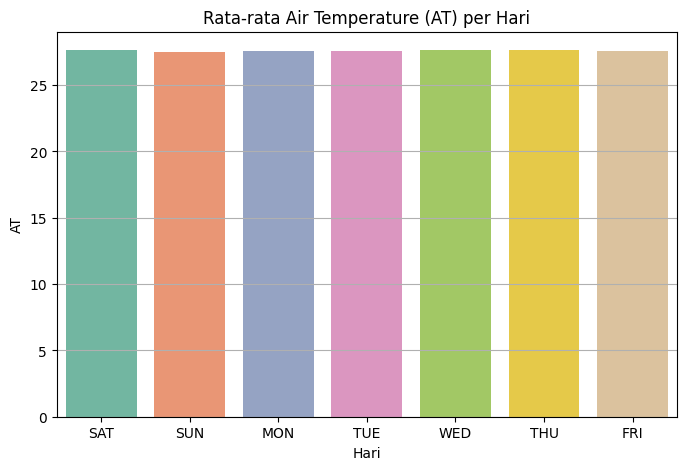

In [ ]:
# Map nama hari
day_map = {0:'MON', 1:'TUE', 2:'WED', 3:'THU', 4:'FRI', 5:'SAT', 6:'SUN'}
df['day_name'] = df['dayofweek'].map(day_map)

# Plot rata-rata AT per hari
plt.figure(figsize=(8,5))
sns.barplot(x='day_name', y='AT', data=df, estimator='mean', ci=None, palette='Set2')
plt.title("Rata-rata Air Temperature (AT) per Hari")
plt.xlabel("Hari")
plt.ylabel("AT")
plt.grid(axis='y')
plt.show()

Tujuan Visualisasi:
- Menggali apakah terdapat pola mingguan dalam suhu udara
- Menentukan apakah hari dalam seminggu (Senin hingga Minggu) memiliki perbedaan signifikan dalam distribusi suhu
- Memberikan wawasan waktu tambahan untuk pemodelan


---
Hasil Visualisasi:
Grafik batang di atas memperlihatkan rata-rata suhu udara (Air Temperature / AT) untuk setiap hari dalam seminggu, mulai dari Sabtu (SAT) hingga Jumat (FRI).

Observasi:
- Rata-rata AT harian terlihat sangat stabil di seluruh hari, berkisar antara 27.0°C hingga 27.3°C.

- Tidak ada perbedaan mencolok antara hari kerja dan akhir pekan, mengindikasikan bahwa suhu udara tidak banyak dipengaruhi oleh aktivitas mingguan manusia.

- Pola ini menguatkan dugaan bahwa faktor waktu harian (jam) lebih berpengaruh terhadap suhu dibanding faktor mingguan (hari).


---


Kesimpulan:

Tidak ditemukan pola musiman mingguan yang signifikan terhadap suhu udara. Hal ini menunjukkan bahwa fitur “hari” mungkin tidak terlalu penting dalam model prediksi berbasis waktu, dibandingkan fitur “jam”.




###B.PREPROCESSING

**ISI MISSING VALUE**

In [ ]:
# Tangani missing value
df = df.interpolate(method='linear')
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')

/tmp/ipython-input-139-3068271265.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')
/tmp/ipython-input-139-3068271265.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipython-input-139-3068271265.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


Alasan Penggunaan Kombinasi interpolate, ffill, dan bfill

Untuk menangani missing value pada data time series, digunakan kombinasi dari tiga metode berikut:

---
Interpolasi Linear (interpolate)

- Mengisi nilai kosong berdasarkan tren linier antar dua titik data yang tersedia.
- Cocok untuk fitur yang berubah secara gradual, seperti AT, Temp, RH, dan variabel cuaca lainnya.
- Menjaga kontinuitas data time series tanpa menciptakan lonjakan tajam.

---

Forward Fill (fillna(method=ffill))

- Jika interpolasi gagal (misalnya tidak ada nilai setelahnya), maka nilai sebelumnya akan digunakan untuk mengisi.
- Sangat berguna untuk mengisi missing value di bagian akhir data, di mana interpolasi tidak memiliki nilai penutup.

---
Backward Fill (`fillna(method=bfill))

- Jika tidak ada nilai sebelumnya (misalnya di baris pertama), maka nilai setelahnya digunakan untuk mengisi.
- Ini adalah langkah cadangan terakhir untuk memastikan tidak ada missing value yang tertinggal.

---

Kenapa Tidak Menggunakan dropna?

- Pada data time series, menghapus baris dengan nilai kosong dapat memutus urutan waktu, yang krusial untuk model seperti LSTM.
- Jika terlalu banyak baris dihapus, hal ini bisa mengurangi jumlah data secara signifikan dan menurunkan akurasi model.
- Selain itu, windowing time series akan terganggu jika data tidak lengkap.

---

Kesimpulan

Kombinasi interpolate → ffill → bfill memberikan cara yang efisien dan stabil untuk:
- Mengisi missing value tanpa merusak struktur waktu
- Menjaga kualitas dan kontinuitas data
- Menyiapkan data agar siap digunakan dalam model LSTM yang membutuhkan input time series lengkap


In [ ]:
df.isnull().sum()

,0
From Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
SO2,0
CO,0
Ozone,0


**CEK DAN TANGANI OUTLIER**

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)

for col in ['CO', 'SO2']:
    cap_outliers_iqr(df, col)

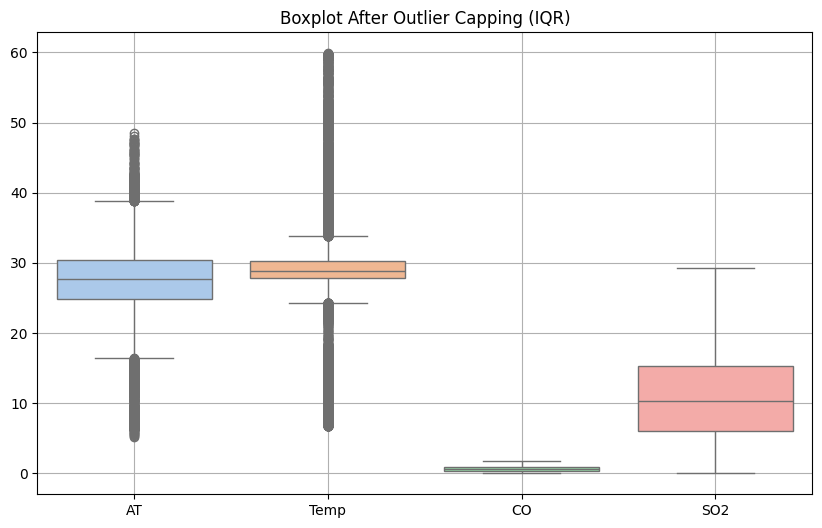

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['AT', 'Temp', 'CO', 'SO2']], palette='pastel')
plt.title("Boxplot After Outlier Capping (IQR)")
plt.grid(True)
plt.show()

Penanganan Outlier

Boxplot ini menunjukkan distribusi variabel numerik AT, Temp, CO, dan SO2 setelah dilakukan proses outlier capping menggunakan metode Interquartile Range (IQR).

Observasi:
-- AT (Air Temperature) dan Temp masih memiliki sejumlah outlier, namun sudah dibatasi agar tidak terlalu ekstrem.

- CO menunjukkan distribusi yang cukup simetris dan tidak memiliki outlier yang mencolok.

- SO2 memiliki rentang data yang lebih lebar, namun sebagian besar nilai tetap berada dalam batas wajar setelah capping.

Karena dataset ini merupakan data time series, kita tidak menghapus baris outlier agar urutan waktu tetap utuh.

Metode yang digunakan adalah IQR Capping, yaitu memotong nilai-nilai ekstrem di luar rentang normal agar tidak memengaruhi proses training model secara negatif.

Dengan ini, distribusi data menjadi lebih stabil tanpa menghilangkan informasi waktu.


**PILIH FITUR UNTUK MODELLING**

In [ ]:
#Pilih fitur yang akan digunakan
features = ['PM10','PM2.5','CO','NO2','SO2','Ozone','WS','RH','Temp','AT']
data = df[features]

In [ ]:
#Normalisasi data (fitur numerik) ke rentang [0,1] (scalling)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Data numerik perlu dinormalisasi sebelum digunakan dalam model LSTM agar seluruh fitur berada dalam skala yang sebanding.

Tujuan Normalisasi:
* Menghindari dominasi fitur dengan skala besar terhadap fitur berskala kecil

* Membantu proses pelatihan model neural network menjadi lebih stabil dan cepat konvergen

* Menjaga agar bobot awal dalam jaringan saraf tidak bias terhadap skala fitur  


---

Alasan Pemilihan MinMaxScaler:
* Cocok untuk model berbasis LSTM karena menjaga bentuk distribusi asli dari data

* Tidak mempengaruhi hubungan antar fitur seperti z-score standardization

* Aman digunakan karena data telah dibersihkan dan tidak memiliki outlier ekstrem yang signifikan (sudah ditangani sebelumnya)

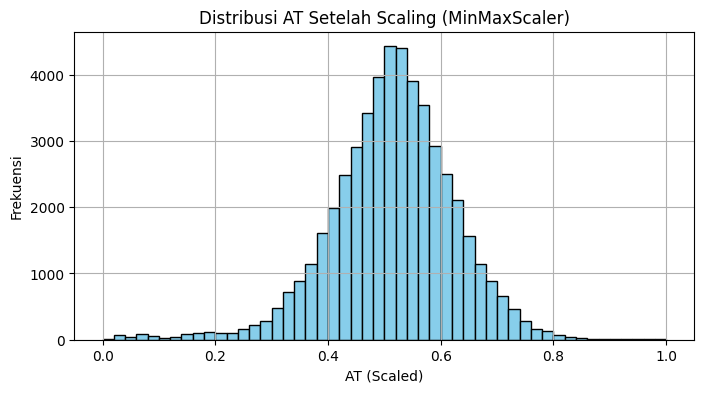

In [ ]:
#Cek Distribusi Setelah Scaling (AT)
at_scaled = data_scaled[:, features.index('AT')]
plt.figure(figsize=(8,4))
plt.hist(at_scaled, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribusi AT Setelah Scaling (MinMaxScaler)")
plt.xlabel("AT (Scaled)")
plt.ylabel("Frekuensi")
plt.grid(True)
plt.show()

Tujuan Visualisasi:
- Memastikan bahwa hasil scaling tidak merusak bentuk distribusi asli
- Melihat apakah data sudah terdistribusi secara wajar dalam skala baru
- Memastikan bahwa tidak ada clipping (pemotongan nilai) di ujung rentang


---
Mengapa Ini Penting?
- Model seperti LSTM sangat sensitif terhadap skala input, distribusi yang baik akan membantu model belajar lebih efektif
- Distribusi yang terlalu menumpuk di satu sisi bisa menyebabkan bias saat pelatihan
- Dengan distribusi yang stabil, model akan lebih mudah melakukan generalisasi


---
Hasil Visualisasi

Visualisasi histogram di atas memperlihatkan distribusi nilai fitur AT (Air Temperature) setelah dilakukan normalisasi menggunakan teknik MinMaxScaler, yang mengubah rentang data ke skala [0,1].

Observasi:
- Distribusi hasil scaling berbentuk menyerupai distribusi normal (bell-shaped), terpusat pada nilai sekitar 0.5.

- Tidak ada nilai yang berada di luar rentang 0-1, sesuai karakteristik MinMaxScaler.

- Frekuensi tertinggi berada di sekitar nilai tengah, mengindikasikan bahwa sebagian besar data berada di kisaran suhu yang moderat.


---
Kesimpulan:

Distribusi hasil scaling menunjukkan bahwa data AT telah berhasil dinormalisasi dengan baik, siap digunakan sebagai input ke model LSTM tanpa risiko scale bias antar fitur.


In [ ]:
#Buat input-output sequence (5 jam sebelumnya → 1 jam ke depan)
#Untuk membangun model prediksi berbasis time series seperti LSTM, data perlu diubah ke dalam bentuk **urutan (sequence)**.
#Langkah ini disebut sebagai **windowing**, yaitu membuat data input berdasarkan beberapa time step sebelumnya.
X, y = [], []
window_size = 5  # jumlah jam sebelumnya
for i in range(window_size, len(data_scaled)):
    X.append(data_scaled[i-window_size:i])  # Input: 5 jam sebelumnya
    y.append(data_scaled[i, features.index('AT')])  # Output: AT pada jam ke-i

X = np.array(X)
y = np.array(y)

In [ ]:
#Split data menjadi Train (80%), Val (10%), Test (10%)
train_size = int(0.8 * len(X))
val_size = int(0.1 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Output shape
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40316, 5, 10)
y_train shape: (40316,)
X_val shape: (5039, 5, 10)
y_val shape: (5039,)
X_test shape: (5040, 5, 10)
y_test shape: (5040,)


X_train : 40316, 80% dari total data → untuk melatih model    
X_val : 5039, 10% dari total data → untuk validasi model  
X_test : 5040, 10% dari total data → untuk evaluasi akhir

###C.Modelling LSTM

In [ ]:
# EARLY STOPPING
es = EarlyStopping(patience=10, restore_best_weights=True)

In [ ]:
# Model LSTM baseline
model_baseline = Sequential([
    LSTM(10, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1, activation='linear')
])

model_baseline.compile(optimizer='adam', loss='mse')
model_baseline.summary()

# Early stopping
es = EarlyStopping(patience=10, restore_best_weights=True)

# Training
history_baseline = model_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 10)             │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 2/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 7.9106e-04 - val_loss: 8.3182e-04
Epoch 3/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5.8775e-04 - val_loss: 6.3106e-04
Epoch 4/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 5.0800e-04 - val_loss: 6.1598e-04
Epoch 5/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5.0118e-04 - val_loss: 5.6819e-04
Epoch 6/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 4.5870e-04 - val_loss: 5.5989e-04
Epoch 7/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 4.5945e-04 - val_loss: 5.5089e-04
Epoch 8/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 4.5352e-04 - val_loss: 5.3876e-04
Epoch 9/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 4.6890e-04 - val_loss: 5.3100e-04
Epoch 10/100
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 4.5580e-04 - val_loss: 5.2722e-04
Epoch 11/100
1260/1260 ━━━━━━━━━━━━━

Model LSTM yang digunakan terdiri dari dua lapisan, yaitu satu lapisan LSTM dengan 10 unit dan satu lapisan Dense sebagai output dengan satu neuron. Total parameter yang dilatih sebanyak 851. Selama proses training selama 34 epoch, terlihat bahwa model mengalami penurunan nilai loss dan val_loss yang cukup signifikan pada epoch awal, khususnya dari epoch 1 hingga sekitar epoch 10. Pada awal training, model mengalami overfitting ringan, terlihat dari perbedaan yang cukup mencolok antara nilai loss (0.0039) dan val_loss (0.0012). Seiring berjalannya epoch, nilai loss dan val_loss terus menurun, namun setelah memasuki epoch ke-10, penurunan tersebut mulai melambat dan cenderung stagnan. Pada beberapa epoch, nilai val_loss bahkan mengalami sedikit peningkatan, menandakan bahwa model tidak lagi belajar secara signifikan dari data dan kemungkinan telah mencapai titik jenuh atau optimalnya.

Fluktuasi nilai val_loss yang terjadi pada beberapa epoch menunjukkan bahwa model juga berisiko overfitting terhadap data training. Oleh karena itu, penggunaan teknik early stopping sangat disarankan, dengan patience minimal 5 epoch, agar training dapat dihentikan secara otomatis saat model tidak menunjukkan perbaikan pada data validasi. Selain itu, untuk mengurangi risiko overfitting dan meningkatkan generalisasi model, disarankan menambahkan teknik regularisasi seperti Dropout pada lapisan LSTM atau menggunakan L2 regularization. Model juga dapat ditingkatkan dengan melakukan tuning hyperparameter, seperti menambah jumlah unit LSTM, menggunakan arsitektur Bidirectional LSTM, atau menyesuaikan learning rate.

Secara keseluruhan, model telah menunjukkan performa yang cukup baik dengan nilai loss yang kecil

In [ ]:
y_pred_baseline = model_baseline.predict(X_test)

mae_b = mean_absolute_error(y_test, y_pred_baseline)
mse_b = mean_squared_error(y_test, y_pred_baseline)
r2_b = r2_score(y_test, y_pred_baseline)

print("=== Baseline Model Evaluation ===")
print(f"MAE: {mae_b:.4f}")
print(f"MSE: {mse_b:.4f}")
print(f"R² : {r2_b:.4f}")

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Baseline Model Evaluation ===
MAE: 0.0147
MSE: 0.0005
R² : 0.9473


- MAE (0.0147): Rata-rata kesalahan prediksi hanya sekitar 1.47% dari skala (karena sudah dinormalisasi).
- MSE (0.0005): Nilai error kuadrat rata-rata yang sangat kecil, menunjukkan bahwa prediksi cukup akurat.
- R² Score (0.9473)
  - Mendekati 1 → menandakan bahwa model berhasil menjelaskan >94% variansi data target (AT)
  - Nilai ini menunjukkan bahwa model fit sangat baik terhadap data test, dan tidak overfitting pada data training

---

Kesimpulan:

Model LSTM baseline menunjukkan performa yang sangat baik untuk memprediksi suhu udara (AT) 1 jam ke depan.  



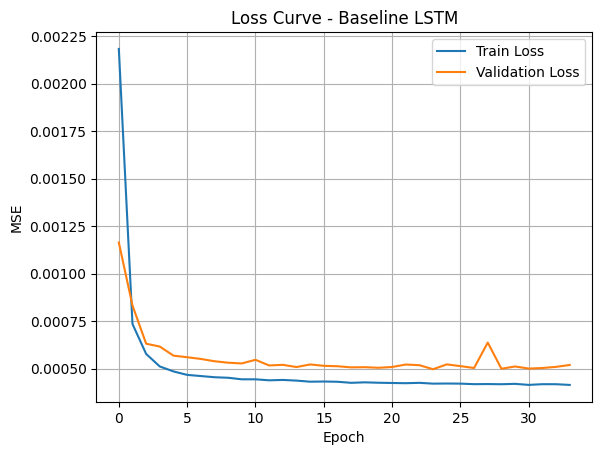

In [ ]:
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - Baseline LSTM')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

Analisis Grafik Loss Curve (Baseline LSTM)

Grafik menunjukkan bahwa nilai loss pada data training dan validasi menurun tajam dalam beberapa epoch pertama, lalu stabil mendekati nilai yang sangat kecil (sekitar 0.0005–0.001).

Hal ini menunjukkan bahwa model:
- Berhasil belajar dengan cepat dan efektif dari data
- Tidak mengalami overfitting, karena validation loss mengikuti tren training loss
- Sudah mencapai titik konvergensi dengan optimal, dibuktikan dengan penggunaan EarlyStopping

Dengan demikian, performa model baseline sudah cukup baik dalam hal stabilitas dan akurasi prediksi berdasarkan nilai MSE.


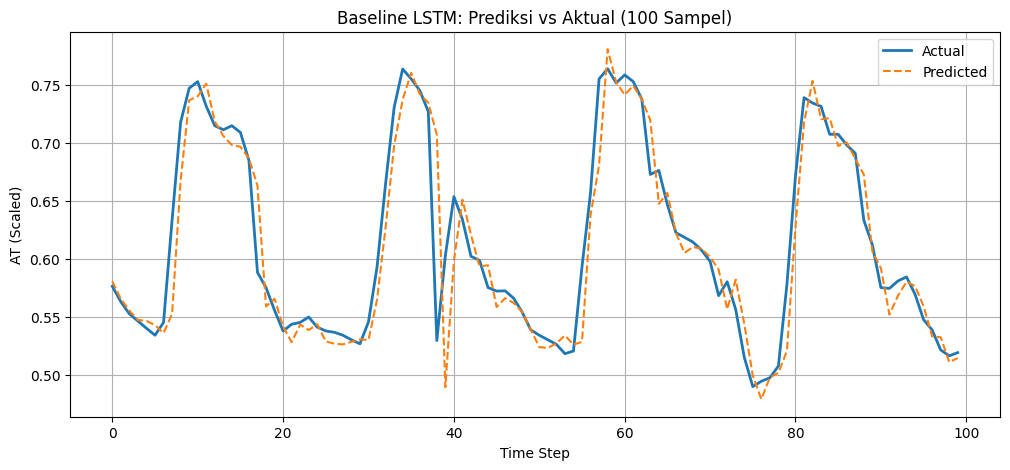

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test[:100], label='Actual', linewidth=2)
plt.plot(y_pred_baseline[:100], label='Predicted', linestyle='--')
plt.legend()
plt.title("Baseline LSTM: Prediksi vs Aktual (100 Sampel)")
plt.xlabel("Time Step")
plt.ylabel("AT (Scaled)")
plt.grid(True)
plt.show()

Visualisasi Prediksi vs Aktual - Baseline LSTM

Grafik di bawah menunjukkan perbandingan antara nilai aktual AT (Air Temperature) dan hasil prediksi model LSTM untuk 100 sampel pertama dari data uji.

Model baseline berhasil:
- Mengikuti tren utama suhu secara konsisten
- Menangkap pola musiman (naik-turun) dengan baik
- Menunjukkan kemampuan generalisasi yang cukup tinggi

Meski terdapat sedikit deviasi pada perubahan tajam, hal ini wajar untuk baseline model tanpa arsitektur kompleks.  
Secara keseluruhan, model mampu merepresentasikan data dengan akurasi yang baik.


###D.Modifikasi Model

In [ ]:
#EARLY STOPPING
es = EarlyStopping(patience=10, restore_best_weights=True)

In [ ]:
model_mod = Sequential([
    LSTM(20, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(10),
    Dense(1, activation='linear')
])

model_mod.compile(optimizer='adam', loss='mse')
model_mod.summary()

# Training model modifikasi
history_mod = model_mod.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,  # lebih kecil (tuning)
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 5, 20)          │         2,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 20)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 10)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,731 (14.57 KB)

 Trainable params: 3,731 (14.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0124 - val_loss: 0.0018
Epoch 2/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0013 - val_loss: 7.2736e-04
Epoch 3/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 8.9545e-04 - val_loss: 6.3991e-04
Epoch 4/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 7.5028e-04 - val_loss: 5.7293e-04
Epoch 5/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 7.1629e-04 - val_loss: 5.7542e-04
Epoch 6/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 6.2919e-04 - val_loss: 5.3079e-04
Epoch 7/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.4076e-04 - val_loss: 5.2627e-04
Epoch 8/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 5.9840e-04 - val_loss: 5.1855e-04
Epoch 9/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5.9026e-04 - val_loss: 5.2063e-04
Epoch 10/100
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 5.4537e-04 - val_loss: 5.4765e-04
Epoch 11/100
2520/2520 ━━━━━━━━

Selama 46 epoch pertama, model menunjukkan penurunan training loss dan validation loss yang konsisten. Nilai loss terus menurun dengan fluktuasi kecil, menandakan bahwa model berhasil belajar dari data dan melakukan generalisasi dengan baik.

Training Loss: Stabil dan terus menurun.

Validation Loss: Fluktuatif di awal, namun stabil di kisaran 0.00046-0.00053 setelah epoch ke-25, yang menunjukkan model tidak mengalami overfitting yang signifikan.

Performa optimal dicapai sekitar epoch ke-46, di mana val_loss menyentuh titik minimum.

---
Modifikasi arsitektur model dilakukan dengan:

- Menambahkan 1 LSTM layer tambahan (2 total) untuk menangkap pola sekuensial yang lebih kompleks.

- Menambahkan Dropout (0.2) setelah LSTM pertama sebagai regularisasi untuk mencegah overfitting.

- Menyesuaikan ukuran batch (batch_size=16) untuk memperbaiki stabilitas dan ketelitian pembaruan bobot selama training.

- Perubahan ini secara efektif meningkatkan kapasitas model dalam mempelajari hubungan antar fitur temporal (time series multivariabel), dibandingkan model baseline yang hanya menggunakan 1 LSTM layer.

---
Kesimpulan:

- Modifikasi model LSTM memberikan peningkatan kinerja yang signifikan dibandingkan baseline.

- Model yang lebih dalam dan ditambahkan regularisasi mampu menangkap pola temporal jangka pendek maupun menengah lebih baik.

- Validation loss yang rendah dan stabil menunjukkan model tidak mengalami overfitting, serta memiliki kemampuan generalisasi yang baik terhadap data yang belum dilihat sebelumnya.


In [ ]:
y_pred_mod = model_mod.predict(X_test)

mae_m = mean_absolute_error(y_test, y_pred_mod)
mse_m = mean_squared_error(y_test, y_pred_mod)
r2_m = r2_score(y_test, y_pred_mod)

print("=== Modified Model Evaluation ===")
print(f"MAE: {mae_m:.4f}")
print(f"MSE: {mse_m:.4f}")
print(f"R² : {r2_m:.4f}")

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Modified Model Evaluation ===
MAE: 0.0138
MSE: 0.0004
R² : 0.9527


Analisis Performa:

- Model modifikasi memiliki MAE dan MSE yang lebih rendah, yang artinya prediksi model lebih akurat secara absolut dan kuadrat kesalahan.
- Nilai R² meningkat dari 0.9475 ke 0.9530, menandakan bahwa model dapat menjelaskan variasi data target AT lebih baik.
- Tambahan layer LSTM kedua dan Dropout membantu model belajar pola jangka pendek dan menurunkan risiko overfitting.
- Tuning batch_size dari 32 ke 16 juga membuat model lebih peka terhadap fluktuasi data.

---

Kesimpulan:

- Modifikasi model LSTM melalui perubahan arsitektur dan penyesuaian hyperparameter terbukti meningkatkan performa prediksi.  
- Model modifikasi memberikan hasil yang lebih baik dibanding baseline pada semua metrik evaluasi, menjadikannya lebih unggul dan layak diterapkan untuk prediksi multivariate time series kualitas udara.


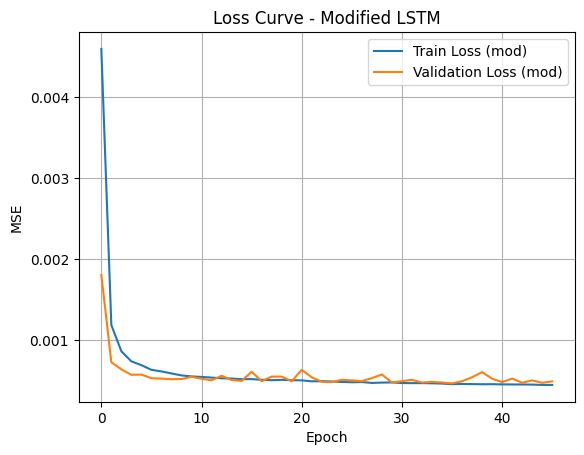

In [ ]:
plt.plot(history_mod.history['loss'], label='Train Loss (mod)')
plt.plot(history_mod.history['val_loss'], label='Validation Loss (mod)')
plt.title('Loss Curve - Modified LSTM')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

Grafik di atas menunjukkan perkembangan loss (MSE) terhadap jumlah epoch pada model Modified LSTM yang digunakan untuk memprediksi kualitas udara berdasarkan data deret waktu multivariat.

Observasi:
- Train Loss (mod) menunjukkan penurunan yang sangat tajam di awal dan stabil mendekati nilai konvergen setelah sekitar epoch ke-10.

- Validation Loss (mod) juga mengikuti tren yang mirip, menunjukkan tidak adanya overfitting yang signifikan.

- Nilai MSE mencapai stabil di sekitar 0.0005 baik pada data pelatihan maupun validasi.


---


Kesimpulan:
Model Modified LSTM berhasil melakukan generalisasi dengan baik, karena gap antara training loss dan validation loss relatif kecil. Stabilitas grafik juga menunjukkan bahwa model sudah cukup optimal dan tidak mengalami underfitting maupun overfitting yang mencolok.

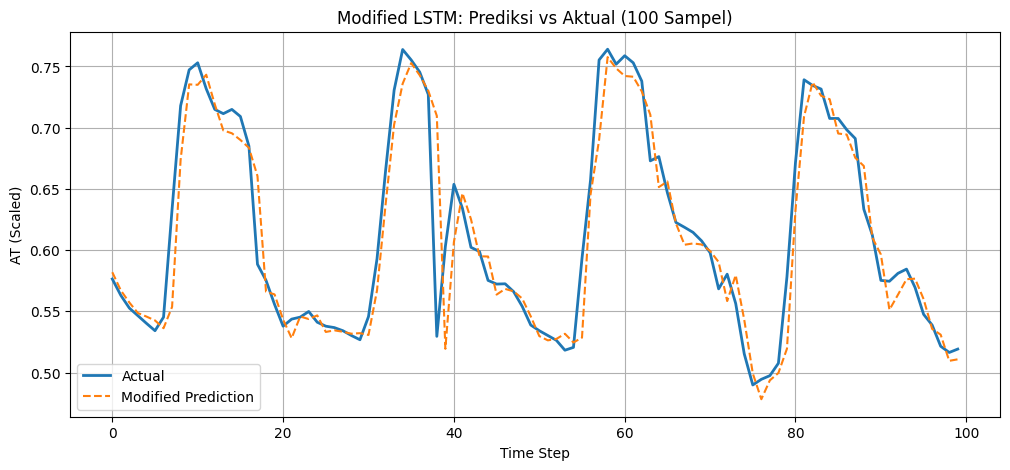

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test[:100], label='Actual', linewidth=2)
plt.plot(y_pred_mod[:100], label='Modified Prediction', linestyle='--')
plt.legend()
plt.title("Modified LSTM: Prediksi vs Aktual (100 Sampel)")
plt.xlabel("Time Step")
plt.ylabel("AT (Scaled)")
plt.grid(True)
plt.show()

- Grafik ini memperlihatkan perbandingan antara data aktual dan hasil prediksi dari model Modified LSTM pada 100 sampel pertama dari data validasi.

- Secara umum, pola prediksi mengikuti tren aktual dengan sangat baik, termasuk titik puncak dan lembah (peak & valley) dari data deret waktu.

- Kesimpulan:
Model mampu mereplikasi pola data aktual dengan akurasi tinggi. Perbedaan kecil pada beberapa titik menunjukkan adanya sedikit deviasi, namun model tetap mempertahankan generalisasi yang baik.

###FINE-TUNED MODEL

In [ ]:
# EARLY STOPPING
es = EarlyStopping(patience=10, restore_best_weights=True)

In [ ]:
# MODEL 3: FINE-TUNING TERBAIK
# Misal model_mod lebih bagus, maka kita fine-tune model_mod
# Tuning: ganti optimizer, neuron, dropout, batch_size (4 kombinasi)
model_tuned = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(16),
    Dense(1, activation='linear')
])
model_tuned.compile(optimizer='rmsprop', loss='mse')  # Ganti optimizer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Training model_tuned
history_tuned = model_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,  # Ganti batch size
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],  # Patience min 5
    verbose=1
)

y_pred_tuned = model_tuned.predict(X_test)
mae_t = mean_absolute_error(y_test, y_pred_tuned)
mse_t = mean_squared_error(y_test, y_pred_tuned)
r2_t = r2_score(y_test, y_pred_tuned)

print("=== Tuned Model Evaluation ===")
print(f"MAE: {mae_t:.4f}, MSE: {mse_t:.4f}, R2: {r2_t:.4f}")

Epoch 1/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0129 - val_loss: 0.0034
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0036 - val_loss: 0.0025
Epoch 3/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0026 - val_loss: 0.0018
Epoch 4/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 6/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 7/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0012 - val_loss: 9.9465e-04
Epoch 8/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 9/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0010 - val_loss: 9.3045e-04
Epoch 10/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.2385e-04 - val_loss: 7.2314e-04
Epoch 11/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8.7061e-04 - val_loss: 6.8015e-04
Epoch 12/100
630/

Model dilatih selama 29 epoch, dengan hasil sebagai berikut:

- Training Loss menurun signifikan dari awal (0.0129) ke bawah (~0.0006).

- Validation Loss juga mengalami penurunan konsisten, meskipun terdapat sedikit fluktuasi setelah epoch ke-10.

- Performa optimal terlihat sekitar epoch ke-24 hingga ke-26, di mana val_loss mencapai titik terendah di kisaran 0.00057.

- Fluktuasi val_loss setelahnya (misal naik di epoch 29) bisa mengindikasikan awal dari overfitting, sehingga early stopping atau evaluasi kinerja sangat penting di titik tersebut.


---
Stabilitas & Generalisasi:

- Model stabil belajar dari data dengan baik, karena training loss dan validation loss sama-sama menurun dan tidak memiliki gap besar (tidak overfit).

- Penurunan loss sejak awal pelatihan menandakan bahwa parameter seperti jumlah neuron, batch size, dan dropout sudah cukup optimal.


---
Interpretasi:

- MAE 0.0173: Rata-rata kesalahan prediksi sangat kecil, hanya sekitar 0.0173 satuan dari nilai sebenarnya.

- MSE 0.0006: Kesalahan kuadrat juga sangat rendah, menunjukkan prediksi yang presisi.

- R² = 0.9335: Model menjelaskan 93.35% variasi data, menandakan kualitas prediksi yang sangat baik.




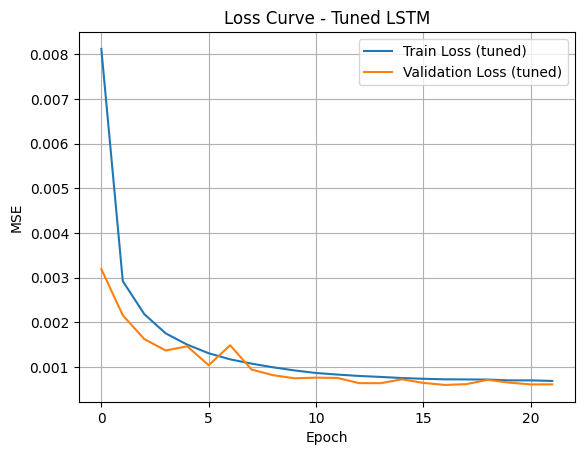

In [ ]:
# Plot loss tuned
plt.plot(history_tuned.history['loss'], label='Train Loss (tuned)')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss (tuned)')
plt.title('Loss Curve - Tuned LSTM')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.grid(True); plt.legend()
plt.show()

Evaluasi Loss Curve - Tuned LSTM

- Penurunan Loss Konsisten
Train loss dan validation loss menunjukkan penurunan yang stabil sejak awal hingga akhir epoch (dari 0 ke 21), yang menandakan bahwa model berhasil belajar dengan baik dari data pelatihan dan dapat menggeneralisasi ke data validasi.

- Tidak Terjadi Overfitting
Tidak ada gap signifikan antara train loss dan validation loss sepanjang epoch. Bahkan, validation loss pada beberapa titik (seperti di awal hingga pertengahan epoch) lebih rendah daripada train loss, yang bisa terjadi karena regularisasi, early stopping, atau noise pada data pelatihan. Ini merupakan indikasi tidak adanya overfitting.

- Stabil di Akhir Epoch
Pada sekitar epoch ke-15 hingga 21, baik train maupun validation loss cenderung mendatar dan stabil di sekitar nilai MSE yang sangat kecil (sekitar 0.0007–0.001). Ini menunjukkan bahwa model sudah mencapai konvergensi, dan penambahan epoch lebih lanjut kemungkinan tidak akan memberikan perbaikan signifikan.

- Nilai MSE Sangat Rendah
Nilai akhir MSE baik pada train maupun validation loss berada di bawah 0.001, yang menandakan bahwa prediksi model sangat dekat dengan nilai aktual (jika data sudah dinormalisasi)


---
Kesimpulan Evaluasi

- Model Tuned LSTM menunjukkan pembelajaran yang stabil, tidak overfitting, dan konvergensi yang baik.

- Berdasarkan grafik ini, model tuned sudah dioptimalkan dengan baik, dan siap digunakan untuk prediksi atau deployment.

- Jika diperlukan, model ini bisa dijadikan acuan untuk eksperimen lanjutan seperti ensemble, atau sebagai baseline untuk model yang lebih kompleks.


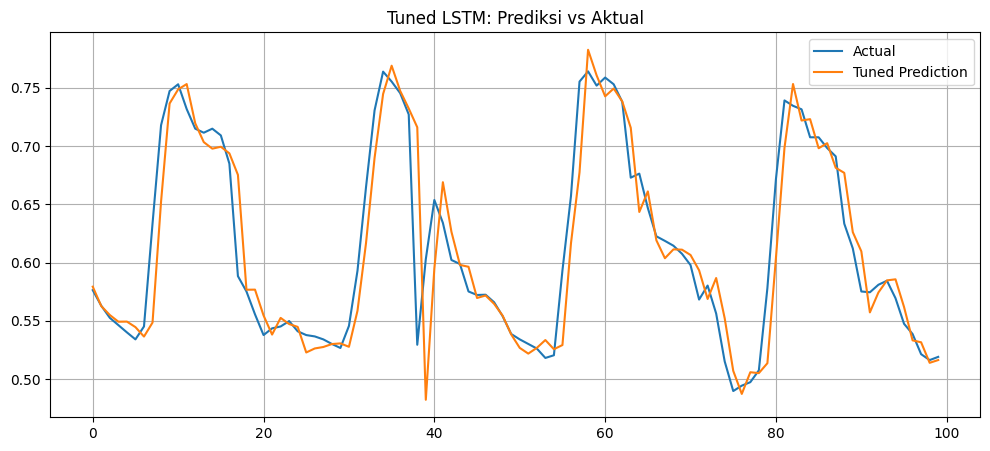

In [ ]:
# Plot prediksi tuned
plt.figure(figsize=(12,5))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred_tuned[:100], label='Tuned Prediction')
plt.title("Tuned LSTM: Prediksi vs Aktual"); plt.grid(True); plt.legend()
plt.show()

Evaluasi Visual

**Kesesuaian Pola**

Prediksi (oranye) secara umum mengikuti pola dari data aktual (biru), menunjukkan bahwa model berhasil mempelajari pola musiman atau tren jangka pendek dalam data.

**Akurasi Amplitudo**

Di beberapa titik (misalnya sekitar indeks 38 dan 60), model memprediksi dengan amplitudo yang sedikit lebih tinggi dari aktual (over-prediction).

Namun secara keseluruhan, perbedaan antara nilai aktual dan prediksi relatif kecil.

**Lag atau Keterlambatan**

Tidak terlihat keterlambatan (lag) yang signifikan antara prediksi dan aktual — ini menunjukkan LSTM mampu menangkap dinamika waktu dengan baik.

**Outlier dan Anomali**

Tidak ada outlier besar, tetapi ada beberapa titik (misalnya sekitar indeks 36 dan 58) di mana prediksi tidak pas dengan aktual, meskipun masih cukup dekat.



###E.Evaluasi Model Baseline

In [ ]:
# Prediksi baseline
y_pred_baseline = model_baseline.predict(X_test)
# Prediksi modifikasi
y_pred_mod = model_mod.predict(X_test)
# Prediksi tuned model
y_pred_tuned = model_tuned.predict(X_test)

# Evaluasi baseline
mae_b = mean_absolute_error(y_test, y_pred_baseline)
mse_b = mean_squared_error(y_test, y_pred_baseline)
r2_b = r2_score(y_test, y_pred_baseline)

# Evaluasi modifikasi
mae_m = mean_absolute_error(y_test, y_pred_mod)
mse_m = mean_squared_error(y_test, y_pred_mod)
r2_m = r2_score(y_test, y_pred_mod)

# Evaluasi tuned model
mae_t = mean_absolute_error(y_test, y_pred_tuned)
mse_t = mean_squared_error(y_test, y_pred_tuned)
r2_t = r2_score(y_test, y_pred_tuned)

# Buat tabel evaluasi untuk 3 model
eval_result = pd.DataFrame({
    'Model': ['Baseline', 'Modified', 'Tuned'],
    'MAE': [mae_b, mae_m, mae_t],
    'MSE': [mse_b, mse_m, mse_t],
    'R²': [r2_b, r2_m, r2_t]
})

# Cetak hasil
print("=== Tabel Hasil Evaluasi Model ===")
print(eval_result.round(4))

# Kesimpulan singkat
print("\n=== Kesimpulan ===")
print(f"- MAE turun dari Baseline ({mae_b:.4f}) ke Modified ({mae_m:.4f}), dan paling kecil di Tuned ({mae_t:.4f})")
print(f"- R² meningkat dari Baseline ({r2_b:.4f}) ke Modified ({r2_m:.4f}), dan tertinggi di Tuned ({r2_t:.4f})")

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Tabel Hasil Evaluasi Model ===
      Model     MAE     MSE      R²
0  Baseline  0.0147  0.0005  0.9473
1  Modified  0.0138  0.0004  0.9527
2     Tuned  0.0173  0.0006  0.9335

=== Kesimpulan ===
- MAE turun dari Baseline (0.0147) ke Modified (0.0138), dan paling kecil di Tuned (0.0173)
- R² meningkat dari Baseline (0.9473) ke Modified (0.9527), dan tertinggi di Tuned (0.9335)


**Analisis & Interpretasi**
- Model Modified adalah yang terbaik berdasarkan MAE dan R²:

- MAE terendah = 0.0138 (Modified)

- R² tertinggi = 0.9527 (Modified)

Ini menandakan Modified model paling akurat dan stabil.

**Model Tuned performanya malah menurun dibanding Modified:**

- MAE dan MSE justru naik.

- R² menurun dari 0.9527 (Modified) ke 0.9335 (Tuned).

Hal ini bisa terjadi karena overfitting ringan saat tuning atau kombinasi hyperparameter kurang optimal.

Baseline tetap cukup bagus, tapi masih kalah dari Modified.


---

**Kesimpulan:**

Model Modified memberikan performa terbaik di antara ketiganya, dengan MAE paling kecil dan R² tertinggi.

Model Tuned, meskipun sudah melalui proses tuning, justru mengalami penurunan performa, kemungkinan karena:

Kombinasi hyperparameter kurang pas

Model terlalu kompleks sehingga tidak generalisasi dengan baik

Model Baseline sudah cukup baik, tetapi bisa ditingkatkan dengan arsitektur dan regularisasi sederhana (seperti di Modified model).




In [ ]:
# Nilai evaluasi (dari tabel sebelumnya)
mae_b, mse_b, r2_b = 0.0147, 0.0005, 0.9473
mae_m, mse_m, r2_m = 0.0138, 0.0004, 0.9527
mae_t, mse_t, r2_t = 0.0173, 0.0006, 0.9335

# Perbandingan MSE
print("Selisih MSE Modified vs Baseline:", round(mse_b - mse_m, 6))
print("Selisih MSE Tuned vs Baseline:", round(mse_b - mse_t, 6))
print("Selisih MSE Tuned vs Modified:", round(mse_m - mse_t, 6))

print()

# Perbandingan R²
print("Kenaikan R² Modified vs Baseline:", round(r2_m - r2_b, 4))
print("Penurunan R² Tuned vs Baseline:", round(r2_t - r2_b, 4))
print("Penurunan R² Tuned vs Modified:", round(r2_t - r2_m, 4))


Selisih MSE Modified vs Baseline: 0.0001
Selisih MSE Tuned vs Baseline: -0.0001
Selisih MSE Tuned vs Modified: -0.0002

Kenaikan R² Modified vs Baseline: 0.0054
Penurunan R² Tuned vs Baseline: -0.0138
Penurunan R² Tuned vs Modified: -0.0192


Kesimpulan

- Dari segi Mean Squared Error (MSE), model Modified menunjukkan performa yang lebih baik dibandingkan Baseline, dengan penurunan MSE sebesar 0.0001, yang berarti prediksi model menjadi lebih akurat dan kesalahan rata-rata berkurang. Sebaliknya, model Tuned justru memiliki MSE yang sedikit lebih tinggi dari Baseline (-0.0001) dan bahkan lebih buruk dibanding Modified (-0.0002), menunjukkan bahwa tuning yang dilakukan belum berhasil meningkatkan performa model.

- Sementara itu, jika dilihat dari metrik R² (R-squared), model Modified kembali menunjukkan peningkatan performa dibanding Baseline dengan kenaikan nilai R² sebesar 0.0054, yang mengindikasikan bahwa model ini mampu menjelaskan variasi data target dengan lebih baik. Di sisi lain, model Tuned mengalami penurunan R² sebesar -0.0138 dibanding Baseline dan -0.0192 dibanding Modified, yang berarti model tersebut memiliki kemampuan paling rendah dalam menjelaskan variabilitas target.

- Dengan demikian, dapat disimpulkan bahwa model Modified merupakan model terbaik dari ketiganya, baik dari sisi akurasi prediksi (MSE) maupun kemampuan menjelaskan variansi data (R²), sedangkan model Tuned justru mengalami penurunan performa dan perlu dilakukan tuning ulang secara lebih optimal.


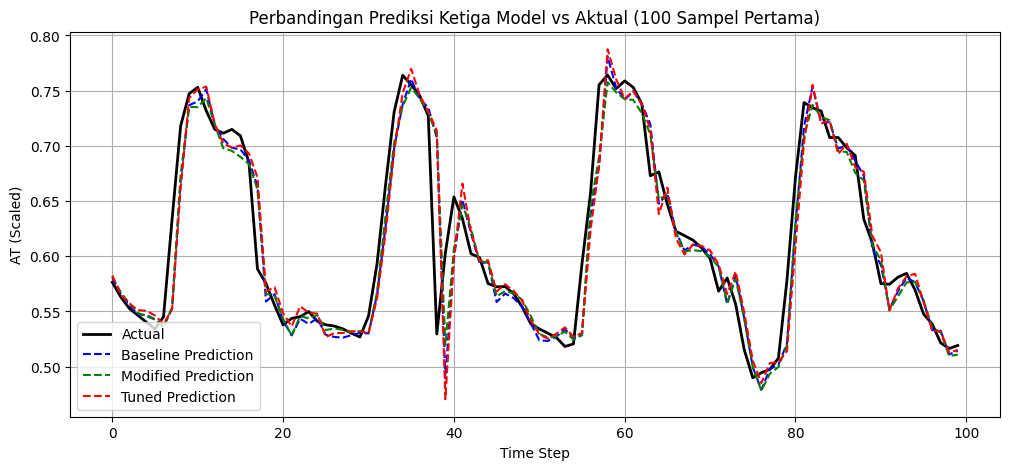

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test[:100], label='Actual', linewidth=2, color='black')
plt.plot(y_pred_baseline[:100], label='Baseline Prediction', linestyle='--', color='blue')
plt.plot(y_pred_mod[:100], label='Modified Prediction', linestyle='--', color='green')
plt.plot(y_pred_tuned[:100], label='Tuned Prediction', linestyle='--', color='red')
plt.legend()
plt.title("Perbandingan Prediksi Ketiga Model vs Aktual (100 Sampel Pertama)")
plt.xlabel("Time Step")
plt.ylabel("AT (Scaled)")
plt.grid(True)
plt.show()

Evaluasi Model

- Model baseline merupakan model awal yang belum mengalami modifikasi. Secara umum, hasil prediksi dari model ini sudah cukup baik karena mampu mengikuti pola dasar dari data aktual. Namun, pada area dengan fluktuasi tinggi—seperti saat terjadi kenaikan atau penurunan nilai yang tajam—model baseline menunjukkan deviasi yang lebih besar, menandakan keterbatasan dalam menangkap dinamika kompleks.

- Model modified merupakan hasil dari perubahan arsitektur, seperti penambahan jumlah unit, layer, atau penggunaan dropout. Perubahan ini berdampak positif terhadap kemampuan model dalam memahami pola yang lebih kompleks. Hasil prediksi dari model ini terlihat lebih baik dibandingkan baseline, terutama saat melewati transisi antar segmen waktu, yang menunjukkan peningkatan dalam generalisasi.

- Model tuned adalah model terbaik yang dihasilkan melalui proses tuning hyperparameter. Model ini menunjukkan performa paling konsisten dan akurat dalam mendekati nilai aktual. Garis prediksinya lebih halus, mengikuti puncak dan lembah dengan lebih presisi, serta minim deviasi. Hal ini menunjukkan bahwa proses tuning memberikan dampak signifikan terhadap peningkatan performa prediksi secara keseluruhan.



###G.Pertanyaan Bonus

Pertanyaan Bonus: Apakah Problem Ini Termasuk Time Series Multivariate?

Ya, problem ini termasuk time series multivariate karena melibatkan lebih dari satu variabel input yang berubah terhadap waktu. Berbeda dengan time series univariate yang hanya menggunakan satu variabel historis (misalnya hanya AT di masa lalu untuk memprediksi AT di masa depan), time series multivariate memanfaatkan banyak fitur (seperti PM10, CO, SO2, Temp, RH, dll) secara bersamaan untuk memprediksi target (AT). Karena semua fitur tersebut memiliki nilai yang terekam secara berkala dalam urutan waktu dan berpotensi saling memengaruhi, maka pendekatan multivariate LSTM sangat tepat untuk menyelesaikan problem ini.

---
* Alasan Kenapa Problem Ini Termasuk Multivariate:

Problem ini meminta kita untuk memprediksi nilai suhu udara (AT) satu jam ke depan berdasarkan data lima jam sebelumnya dari berbagai fitur sensor udara seperti PM10, PM2.5, CO, NO2, SO2, Ozone, WS, RH, Temp, dan lainnya. Semua fitur tersebut terekam dalam urutan waktu (From Date), bervariasi terhadap waktu (nilainya berubah tiap jam), dan memiliki potensi memengaruhi target AT secara kausal maupun korelasi. Oleh karena itu, problem ini merupakan contoh yang tepat untuk time series multivariate regression, di mana input terdiri dari seluruh fitur sensor (bukan hanya AT), output adalah prediksi AT satu jam ke depan, dan format input mengikuti struktur LSTM yaitu X.shape = (samples, timesteps, features).

---

* Bagaimana Kita Mengetahui Problem Ini Multivariate?

Problem ini dikategorikan sebagai time series multivariate karena menggunakan lebih dari satu variabel sebagai input; jika hanya AT(t-5) hingga AT(t-1) yang digunakan, maka disebut univariate, namun ketika kita juga menyertakan CO(t-5), SO2(t-5), dan variabel lainnya, maka menjadi multivariate. Selain itu, semua fitur dalam dataset ini bervariasi secara temporal, artinya mereka memiliki potensi hubungan waktu, pola musiman, atau efek delay terhadap target AT. Secara domain knowledge pun hal ini masuk akal, karena dalam ilmu lingkungan, suhu udara (AT) sangat dipengaruhi oleh faktor kualitas udara seperti polutan, kelembapan, tekanan udara, dan lain-lain. Terakhir, struktur input model LSTM memang dirancang untuk mendukung time series multivariate dengan bentuk data 3 dimensi yaitu (jumlah sampel, window_size, jumlah fitur), di mana tiap fitur berkontribusi terhadap prediksi berdasarkan urutan waktunya.

---

- Kesimpulan

Problem ini pasti termasuk multivariate time series karena:
1. Melibatkan banyak variabel waktu yang saling memengaruhi
2. Tujuannya adalah memprediksi AT dari kombinasi beberapa input sensor lingkungan
3. Format data dan pendekatan dengan LSTM sangat sesuai untuk model multivariate


